In [1]:
# ═══════════════════════════════════════════════════════════
# Kaggle Notebook: PhysIDS_Tier1_HAI22.04_MemoryOptimized
# GPU: ON (P100 recommended)
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
import json
import joblib
import gc  # Garbage Collector — لتحرير الذاكرة
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU Available: []


2026-07-16 21:10:24.290191: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# ═══════════════════════════════════════════════════════════
#  إعدادات HAI 22.04
# ═══════════════════════════════════════════════════════════
DATASET_PATH = '/kaggle/input/datasets/icsdataset/hai-security-dataset/hai-22.04'

# ─────────────────────────────────────────────────────────
# إعدادات النوافذ والأبعاد
# ─────────────────────────────────────────────────────────
WINDOW_SIZE = 60     # 60 نقاط ≈ 0.7 ثانية (HAI = 86 pts/sec)
STRIDE = 5           # تخطي كل 5 نوافذ (يقلل الذاكرة بـ 5x)
BATCH_SIZE = 64
LATENT_DIM = 8       # ضغط أقوى (كان 16)

# ─────────────────────────────────────────────────────────
# إعدادات التدريب
# ─────────────────────────────────────────────────────────
LEARNING_RATE = 0.0005   # أبطأ (كان 0.001)
TRAIN_RATIO = 0.80       # 80% تدريب، 20% تحقق (زمني)
MAX_EPOCHS = 50
PATIENCE_EARLY = 10      # Early Stopping patience
PATIENCE_LR = 4          # ReduceLROnPlateau patience

print(f"\n{'='*60}")
print("📋 PhysIDS v2.0 — Settings")
print(f"{'='*60}")
print(f"📂 Dataset Path: {DATASET_PATH}")
print(f"🪟 Window Size:  {WINDOW_SIZE} (~{WINDOW_SIZE/86:.2f} sec)")
print(f"👣 Stride:        {STRIDE} (memory reduction: {STRIDE}x)")
print(f"📦 Batch Size:    {BATCH_SIZE}")
print(f"🧠 Latent Dim:    {LATENT_DIM}")
print(f"📐 Learning Rate: {LEARNING_RATE}")
print(f"📊 Train Ratio:   {TRAIN_RATIO:.0%}")
print(f"🎯 Max Epochs:    {MAX_EPOCHS}")


📋 PhysIDS v2.0 — Settings
📂 Dataset Path: /kaggle/input/datasets/icsdataset/hai-security-dataset/hai-22.04
🪟 Window Size:  60 (~0.70 sec)
👣 Stride:        5 (memory reduction: 5x)
📦 Batch Size:    64
🧠 Latent Dim:    8
📐 Learning Rate: 0.0005
📊 Train Ratio:   80%
🎯 Max Epochs:    50


In [3]:
# ═══════════════════════════════════════════════════════════
# STEP 1: DATA LOADING (HAI 22.04)
# ═══════════════════════════════════════════════════════════

print("\n" + "="*60)
print("STEP 1: DATA LOADING")
print("="*60)

# ─────────────────────────────────────────────────────────
# 1.1 اكتشاف الملفات
# ─────────────────────────────────────────────────────────

train_files = sorted(glob.glob(f'{DATASET_PATH}/train*.csv'))
test_files = sorted(glob.glob(f'{DATASET_PATH}/test*.csv'))

print(f"\n📁 Train files: {len(train_files)}")
for f in train_files:
    print(f"   • {os.path.basename(f)}")

print(f"\n📁 Test files: {len(test_files)}")
for f in test_files:
    print(f"   • {os.path.basename(f)}")



STEP 1: DATA LOADING

📁 Train files: 6
   • train1.csv
   • train2.csv
   • train3.csv
   • train4.csv
   • train5.csv
   • train6.csv

📁 Test files: 4
   • test1.csv
   • test2.csv
   • test3.csv
   • test4.csv


In [4]:

# ─────────────────────────────────────────────────────────
# 1.2 تحميل ملف واحد فقط لاكتشاف الأعمدة (بدون استهلاك ذاكرة)
# ─────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import gc

print("\n📋 Inspecting schema from train1.csv...")

# 1. نقرأ أول 5 صفوف دون تحديد نوع البيانات دفعة واحدة لتفادي مشكلة عمود الوقت
sample_df = pd.read_csv(train_files[0], nrows=5)

print(f"   Columns: {len(sample_df.columns)}")
print(f"   First column: {sample_df.columns[0]}")
print(f"   Last columns: {list(sample_df.columns[-5:])}")

# 2. تحديد عمود الوقت (وهو العمود الأول دائماً)
time_col = sample_df.columns[0]

# 3. تحديد عمود التسمية بشكل مرن (يتحقق من الحرف الكبير والصغير)
if 'Attack' in sample_df.columns:
    label_col = 'Attack'
elif 'attack' in sample_df.columns:
    label_col = 'attack'
else:
    # في ملفات التدريب الطبيعية (Train) قد لا يوجد عمود الهجوم أصلاً في بعض النسخ
    label_col = None 

# 4. تحديد أعمدة الميزات (كل الأعمدة عدا الوقت والـ label إن وجد)
exclude_cols = [time_col]
if label_col:
    exclude_cols.append(label_col)


feature_cols = [c for c in sample_df.columns if c not in exclude_cols]
n_features = len(feature_cols)

print(f"\n⏰ Time column: {time_col}")
print(f"🎯 Label column: {label_col if label_col else 'None (Normal Data)'}")
print(f"🔧 Features count: {n_features}")

# 5. تنظيف الذاكرة فوراً
del sample_df
gc.collect()



📋 Inspecting schema from train1.csv...
   Columns: 88
   First column: timestamp
   Last columns: ['P4_ST_PO', 'P4_ST_PS', 'P4_ST_PT01', 'P4_ST_TT01', 'Attack']

⏰ Time column: timestamp
🎯 Label column: Attack
🔧 Features count: 86


0

In [5]:
# ─────────────────────────────────────────────────────────
# 1.3 تحميل ودمج كل التدريب (كـ float32 لتوفير الذاكرة بأمان)
# ─────────────────────────────────────────────────────────

print("\n📥 Loading all train files (float32)...")
train_parts = []

for f in train_files:
    # 1. نقرأ الملف ونجعل عمود الوقت هو الفهرس (index) حتى لا يتأثر بالتحويل الرقمي
    df = pd.read_csv(f, index_col=time_col)
    
    # 2. الآن نحول باقي الأعمدة الفيزيائية بأمان إلى float32
    df = df.astype(np.float32)
    
    # 3. حساب عدد الهجمات بأمان (إن وجد عمود الهجوم، وإلا نعتبره 0)
    if label_col in df.columns:
        attacks = int(df[label_col].sum())
    else:
        attacks = 0
        
    print(f"   {os.path.basename(f)}: {df.shape} | Attacks: {attacks}")
    train_parts.append(df)

# دمج الأجزاء
hai_train = pd.concat(train_parts)
print(f"\n✅ Merged TRAIN: {hai_train.shape}")


📥 Loading all train files (float32)...
   train1.csv: (93601, 87) | Attacks: 0
   train2.csv: (201600, 87) | Attacks: 0
   train3.csv: (126000, 87) | Attacks: 0
   train4.csv: (86401, 87) | Attacks: 0
   train5.csv: (237600, 87) | Attacks: 0
   train6.csv: (259200, 87) | Attacks: 0

✅ Merged TRAIN: (1004402, 87)


In [6]:
# ─────────────────────────────────────────────────────────
# 1.4 تحميل ودمج كل الاختبار (كـ float32 لتوفير الذاكرة بأمان)
# ─────────────────────────────────────────────────────────

print("\n📥 Loading all test files (float32)...")
test_parts = []

for f in test_files:
    # 1. نقرأ الملف ونجعل عمود الوقت هو الفهرس (index) لتفادي خطأ تحويل النص إلى float
    df = pd.read_csv(f, index_col=time_col)
    
    # 2. تحويل باقي الأعمدة الرقمية (الميزات) إلى float32 لتوفير الذاكرة
    df = df.astype(np.float32)
    
    # 3. حساب عدد الهجمات بأمان (إن وجد عمود الهجوم، وإلا نعتبره 0)
    # ملاحظة: في الإصدارات الحديثة، قد تحتاج لدمج ملف الـ label لاحقاً إذا لم يكن موجوداً هنا
    if label_col in df.columns:
        attacks = int(df[label_col].sum())
    else:
        attacks = 0
        
    print(f"   {os.path.basename(f)}: {df.shape} | Attacks: {attacks}")
    test_parts.append(df)

# دمج ملفات الاختبار
hai_test = pd.concat(test_parts)
print(f"\n✅ Merged TEST: {hai_test.shape}")


📥 Loading all test files (float32)...
   test1.csv: (86400, 87) | Attacks: 885
   test2.csv: (82800, 87) | Attacks: 2881
   test3.csv: (62400, 87) | Attacks: 3841
   test4.csv: (129600, 87) | Attacks: 4423

✅ Merged TEST: (361200, 87)


In [7]:
# ─────────────────────────────────────────────────────────
# 1.5 فصل Normal vs Attack
# ─────────────────────────────────────────────────────────

print("\n📊 Data split:")

# التدريب: فقط Normal (تحقق)
train_normal_mask = hai_train[label_col] == 0
hai_normal_train = hai_train.loc[train_normal_mask, feature_cols].copy()

# الاختبار: Normal + Attack
test_normal_mask = hai_test[label_col] == 0
test_attack_mask = hai_test[label_col] == 1

hai_normal_test = hai_test.loc[test_normal_mask, feature_cols].copy()
hai_attack_test = hai_test.loc[test_attack_mask, feature_cols].copy()

print(f"   Train Normal: {hai_normal_train.shape}")
print(f"   Test Normal:  {hai_normal_test.shape}")
print(f"   Test Attack:  {hai_attack_test.shape}")


📊 Data split:
   Train Normal: (1004402, 86)
   Test Normal:  (349170, 86)
   Test Attack:  (12030, 86)


In [8]:
# ─────────────────────────────────────────────────────────
# 1.6 حفظ المعلومات
# ─────────────────────────────────────────────────────────

metadata = {
    'hai_version': '22.04',
    'train_files': [os.path.basename(f) for f in train_files],
    'test_files': [os.path.basename(f) for f in test_files],
    'n_features': n_features,
    'feature_names': feature_cols,
    'time_column': time_col,
    'label_column': label_col
}
with open('tier1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n💾 Metadata saved")
print(f"\n✅ Step 1 complete!")


💾 Metadata saved

✅ Step 1 complete!


**🧹 الخطوة 2: تنظيف وتحضير البيانات**


In [9]:
# ═══════════════════════════════════════════════════════════
# STEP 2: PREPROCESSING (مُحسّن ضد OOM)
# ═══════════════════════════════════════════════════════════

print("\n" + "="*60)
print("STEP 2: PREPROCESSING")
print("="*60)

# ─────────────────────────────────────────────────────────
# 2.1 معالجة القيم المفقودة
# ─────────────────────────────────────────────────────────

print("\n📌 Missing values...")
missing_train = hai_normal_train.isnull().sum().sum()
if missing_train > 0:
    print(f"   Filling {missing_train} missing values...")
    hai_normal_train = hai_normal_train.ffill().bfill()
else:
    print("   ✅ No missing values in train")


STEP 2: PREPROCESSING

📌 Missing values...
   ✅ No missing values in train


In [10]:
# ─────────────────────────────────────────────────────────
# 2.2 إزالة الأعمدة الثابتة
# ─────────────────────────────────────────────────────────

print("\n📌 Constant columns...")
constant_cols = hai_normal_train.columns[hai_normal_train.std() == 0].tolist()

if constant_cols:
    print(f"   Removing {len(constant_cols)}: {constant_cols[:3]}...")
    hai_normal_train = hai_normal_train.drop(columns=constant_cols)
    hai_normal_test = hai_normal_test.drop(columns=constant_cols)
    hai_attack_test = hai_attack_test.drop(columns=constant_cols)
    feature_cols = [c for c in feature_cols if c not in constant_cols]
    n_features = len(feature_cols)
    print(f"   ✅ Remaining features: {n_features}")
else:
    print("   ✅ No constant columns")



📌 Constant columns...
   Removing 13: ['P1_PIT01_HH', 'P1_PP01AD', 'P1_PP01AR']...
   ✅ Remaining features: 73


In [11]:
# ─────────────────────────────────────────────────────────
# 2.3 التطبيع (Fit على التدريب فقط)
# ─────────────────────────────────────────────────────────

print("\n📌 Fitting StandardScaler...")
scaler = StandardScaler()

# Fit على البيانات الطبيعية من التدريب
X_train_raw = hai_normal_train.values  # numpy array
scaler.fit(X_train_raw)

print(f"   ✅ Scaler fitted on {X_train_raw.shape[0]:,} samples")

# Transform بيانات الاختبار (التدريب سنحوله لاحقاً ملفاً ملفاً)
X_test_normal_raw = hai_normal_test.values
X_test_attack_raw = hai_attack_test.values

X_test_normal_scaled = scaler.transform(X_test_normal_raw)
X_test_attack_scaled = scaler.transform(X_test_attack_raw)

print(f"   Test Normal scaled: {X_test_normal_scaled.shape}")
print(f"   Test Attack scaled: {X_test_attack_scaled.shape}")



📌 Fitting StandardScaler...
   ✅ Scaler fitted on 1,004,402 samples
   Test Normal scaled: (349170, 73)
   Test Attack scaled: (12030, 73)


In [12]:
# ─────────────────────────────────────────────────────────
# 2.4 تحرير ذاكرة ضخمة (حذف آمن للمتغيرات)
# ─────────────────────────────────────────────────────────
import gc

print("\n🧹 Freeing memory (deleting large DataFrames)...")

# قائمة بالمتغيرات التي نريد التخلص منها إن وجدت
variables_to_delete = [
    'hai_train', 'hai_test', 'hai_normal_train', 'hai_normal_test', 'hai_attack_test',
    'X_train_raw', 'X_test_normal_raw', 'X_test_attack_raw',
    'train_parts', 'test_parts'
]

# التحقق من وجود المتغير قبل حذفه لتفادي الـ NameError
for var in variables_to_delete:
    if var in globals() or var in locals():
        exec(f"del {var}")
        print(f"   - Deleted: {var}")

# تشغيل جامع القمامة لإجبار النظام على تحرير الذاكرة فوراً
gc.collect()

print("   ✅ Memory freed and optimized!")


🧹 Freeing memory (deleting large DataFrames)...
   - Deleted: hai_train
   - Deleted: hai_test
   - Deleted: hai_normal_train
   - Deleted: hai_normal_test
   - Deleted: hai_attack_test
   - Deleted: X_train_raw
   - Deleted: X_test_normal_raw
   - Deleted: X_test_attack_raw
   - Deleted: train_parts
   - Deleted: test_parts
   ✅ Memory freed and optimized!


In [13]:
# ─────────────────────────────────────────────────────────
# 2.5 إنشاء Generator للـ Sequences (لا يستهلك ذاكرة إضافية!)
# ─────────────────────────────────────────────────────────

print("\n📌 Creating memory-efficient sequence generators...")

def make_autoencoder_dataset(data_array, window_size, batch_size=64, shuffle=True):
    """
    Generator يُنتج Sequences ديناميكياً بدون تخزينها كلها في الذاكرة.
    يحل مشكلة OOM تماماً.
    """
    n_samples = len(data_array) - window_size
    if n_samples <= 0:
        raise ValueError(f"Data too short for window_size={window_size}")
    
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)
    
    def generator():
        for i in indices:
            seq = data_array[i : i + window_size].astype(np.float32)
            yield seq, seq  # (input, target) للـ Autoencoder
    
    output_sig = (
        tf.TensorSpec(shape=(window_size, data_array.shape[1]), dtype=tf.float32),
        tf.TensorSpec(shape=(window_size, data_array.shape[1]), dtype=tf.float32)
    )
    
    ds = tf.data.Dataset.from_generator(generator, output_signature=output_sig)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds



📌 Creating memory-efficient sequence generators...


In [14]:
# ─────────────────────────────────────────────────────────
# 2.6 معالجة التدريب: تقسيم + Generator
# ─────────────────────────────────────────────────────────

print("\n📌 Processing training data per file (to avoid temporal gaps)...")

# ✅ الحل الذكي: نعيد قراءة كل ملف تدريب، نُحوّله، نُنشئ sequences منه
# ثم ندمج الـ indices. هذا يتجنب "القفزات" بين الملفات!

all_train_sequences = []  # قائمة بالـ numpy arrays من كل ملف

for f in train_files:
    df = pd.read_csv(f, usecols=feature_cols + [label_col], dtype=np.float32)
    df_normal = df[df[label_col] == 0].copy()
    
    if len(df_normal) <= WINDOW_SIZE:
        del df, df_normal
        continue
    
    # Transform
    X_scaled = scaler.transform(df_normal[feature_cols].values)
    
    # إنشاء sequences (باستخدام sliding_window — أكثر كفاءة)
    from numpy.lib.stride_tricks import sliding_window_view
    windows = sliding_window_view(X_scaled, WINDOW_SIZE, axis=0)  # (N-W+1, F, W)
    windows = np.transpose(windows, (0, 2, 1))  # (N-W+1, W, F)
    windows = windows[::STRIDE]
    windows = windows.astype(np.float32)
    
    all_train_sequences.append(windows)
    print(f"   {os.path.basename(f)}: {windows.shape[0]:,} sequences")
    
    del df, df_normal, X_scaled, windows
    gc.collect()

# دمج كل sequences
if len(all_train_sequences) == 0:
    raise ValueError("No training sequences created!")

X_train_all_seq = np.vstack(all_train_sequences)
print(f"\n✅ Total train sequences: {X_train_all_seq.shape}")

del all_train_sequences
gc.collect()



📌 Processing training data per file (to avoid temporal gaps)...
   train1.csv: 18,709 sequences
   train2.csv: 40,309 sequences
   train3.csv: 25,189 sequences
   train4.csv: 17,269 sequences
   train5.csv: 47,509 sequences
   train6.csv: 51,829 sequences

✅ Total train sequences: (200814, 60, 73)


0

In [15]:
# ─────────────────────────────────────────────────────────
# 2.7 تقسيم إلى Train / Validation
# ─────────────────────────────────────────────────────────

print("\n📌 Splitting into Train / Validation...")
n_total = X_train_all_seq.shape[0]
split_idx = int(n_total * 0.8)

X_train_seq = X_train_all_seq[:split_idx]
X_val_seq = X_train_all_seq[split_idx:]

print(f"   Train sequences: {X_train_seq.shape[0]:,} (first 80%)")
print(f"   Val sequences:   {X_val_seq.shape[0]:,} (last 20%)")
print(f"   ✅ Chronological split — no data leakage!")


del X_train_all_seq
gc.collect()


📌 Splitting into Train / Validation...
   Train sequences: 160,651 (first 80%)
   Val sequences:   40,163 (last 20%)
   ✅ Chronological split — no data leakage!


0

In [16]:
# ─────────────────────────────────────────────────────────
# 2.8 إنشاء tf.data.Dataset (للتدريب بدون OOM)
# ─────────────────────────────────────────────────────────

print("\n📌 Creating TF Datasets...")

train_ds = tf.data.Dataset.from_tensor_slices(X_train_seq)
train_ds = train_ds.shuffle(buffer_size=10000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(lambda x: (x, x))  # Autoencoder: input = output
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(X_val_seq)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.map(lambda x: (x, x))
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print(f"   ✅ TF Datasets ready (memory-efficient)")



📌 Creating TF Datasets...
   ✅ TF Datasets ready (memory-efficient)


In [17]:
# ─────────────────────────────────────────────────────────
# 2.9 حفظ المعالجات
# ─────────────────────────────────────────────────────────

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

preprocessing_info = {
    'window_size': WINDOW_SIZE,
    'n_features': n_features,
    'feature_names': feature_cols,
    'constant_cols_removed': constant_cols,
    'train_sequences': len(X_train_seq),
    'val_sequences': len(X_val_seq)
}
with open('preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

print(f"\n💾 Scaler & info saved")
print(f"\n✅ Step 2 complete!")


💾 Scaler & info saved

✅ Step 2 complete!


**🧠 الخطوة 3: بناء LSTM Autoencoder**

In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 5: STEP 3 — MODEL BUILDING (Fixed Architecture)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 3: LSTM AUTOENCODER ARCHITECTURE (v2 — Anti-Overfitting)")
print("="*60)

def build_lstm_autoencoder_v2(timesteps, n_features, latent_dim=LATENT_DIM):
    """
    LSTM Autoencoder مُصمّم ضد Overfitting
    
    التغييرات عن v1:
      • LSTM units أصغر: 64→32→16 بدل 128→64→32
      • activation='tanh' بدل 'relu' (أكثر استقراراً في LSTM)
      • Dropout أقوى: 0.3 بدل 0.2
      • L2 Regularization على أوزان LSTM
      • Latent dim أصغر: 8 بدل 16
    """
    print("\n🏗️ Building LSTM Autoencoder v2...")
    
    inputs = layers.Input(shape=(timesteps, n_features), name='input')
    
    # ═══════════════════════════════════════════════════
    # ENCODER (أصغر — ضد Overfitting)
    # ═══════════════════════════════════════════════════
    print("   📥 Encoder: 64 → 32 → 16 (tanh)")
    
    # Layer 1: 64 units
    encoded = layers.LSTM(
        64, activation='tanh', return_sequences=True,
        kernel_regularizer=keras.regularizers.l2(1e-4),
        recurrent_regularizer=keras.regularizers.l2(1e-5),
        name='enc_lstm1'
    )(inputs)
    encoded = layers.BatchNormalization(name='enc_bn1')(encoded)
    encoded = layers.Dropout(0.3, name='enc_drop1')(encoded)
    
    # Layer 2: 32 units
    encoded = layers.LSTM(
        32, activation='tanh', return_sequences=True,
        kernel_regularizer=keras.regularizers.l2(1e-4),
        recurrent_regularizer=keras.regularizers.l2(1e-5),
        name='enc_lstm2'
    )(encoded)
    encoded = layers.BatchNormalization(name='enc_bn2')(encoded)
    encoded = layers.Dropout(0.3, name='enc_drop2')(encoded)
    
    # Layer 3: 16 units (bottleneck)
    encoded = layers.LSTM(
        16, activation='tanh', return_sequences=False,
        name='enc_lstm3'
    )(encoded)
    encoded = layers.Dropout(0.2, name='enc_drop3')(encoded)
    
    # Latent Space
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(encoded)
    latent = layers.Dropout(0.2, name='latent_drop')(latent)
    
    # ═══════════════════════════════════════════════════
    # DECODER (متناظر)
    # ═══════════════════════════════════════════════════
    print("   📤 Decoder: 16 → 32 → 64 (tanh)")
    
    # Expand
    decoded = layers.Dense(16, activation='relu', name='dec_dense1')(latent)
    decoded = layers.Dense(32, activation='relu', name='dec_dense2')(decoded)
    decoded = layers.RepeatVector(timesteps, name='repeat')(decoded)
    
    # Layer 1: 16 units
    decoded = layers.LSTM(
        16, activation='tanh', return_sequences=True,
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dec_lstm1'
    )(decoded)
    decoded = layers.BatchNormalization(name='dec_bn1')(decoded)
    decoded = layers.Dropout(0.3, name='dec_drop1')(decoded)
    
    # Layer 2: 32 units
    decoded = layers.LSTM(
        32, activation='tanh', return_sequences=True,
        name='dec_lstm2'
    )(decoded)
    decoded = layers.BatchNormalization(name='dec_bn2')(decoded)
    decoded = layers.Dropout(0.2, name='dec_drop2')(decoded)
    
    # Layer 3: 64 units
    decoded = layers.LSTM(
        64, activation='tanh', return_sequences=True,
        name='dec_lstm3'
    )(decoded)
    decoded = layers.BatchNormalization(name='dec_bn3')(decoded)
    
    # Output
    outputs = layers.TimeDistributed(
        layers.Dense(n_features), name='output'
    )(decoded)
    
    # ═══════════════════════════════════════════════════
    # COMPILE
    # ═══════════════════════════════════════════════════
    autoencoder = Model(inputs, outputs, name='LSTM_Autoencoder_v2')
    
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipnorm=1.0    # ✅ Gradient Clipping
           
        ),
        loss='mse',
        metrics=['mae']
    )
    
    print("   ✅ Model built and compiled!")
    return autoencoder


# بناء النموذج
model = build_lstm_autoencoder_v2(WINDOW_SIZE, n_features, latent_dim=LATENT_DIM)

print("\n" + "="*60)
print("📊 MODEL SUMMARY")
print("="*60)
model.summary()

total_params = model.count_params()
print(f"\n💾 Parameters: {total_params:,} (~{total_params * 4 / (1024**2):.1f} MB)")
print(f"📉 مقارنة مع v1: ~{total_params / 850000 * 100:.0f}% من حجم النموذج السابق")

print(f"\n✅ Step 3 complete!")




STEP 3: LSTM AUTOENCODER ARCHITECTURE (v2 — Anti-Overfitting)

🏗️ Building LSTM Autoencoder v2...
   📥 Encoder: 64 → 32 → 16 (tanh)
   📤 Decoder: 16 → 32 → 64 (tanh)
   ✅ Model built and compiled!

📊 MODEL SUMMARY


Model: "LSTM_Autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 73)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 60, 64)         │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 60, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 60, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm3 (LSTM)                │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_drop (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1 (Dense)              │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2 (Dense)              │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 60, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 60, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop1 (Dropout)             │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 60, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 60, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm3 (LSTM)                │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn3 (BatchNormalization)    │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 73)         │         4,745 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,521 (357.50 KB)

 Trainable params: 91,105 (355.88 KB)

 Non-trainable params: 416 (1.62 KB)


💾 Parameters: 91,521 (~0.3 MB)
📉 مقارنة مع v1: ~11% من حجم النموذج السابق

✅ Step 3 complete!


**🎓 الخطوة 4: تدريب النموذج**

In [19]:
# حذف الـ checkpoints القديمة (من النموذج v1)
!rm -rf ./training_checkpoints/
!rm -f best_autoencoder.keras
!rm -f best_autoencoder_v2.keras
!rm -f lstm_autoencoder_final.keras
!rm -f lstm_autoencoder_v2_final.keras
print("✅ تم حذف الـ checkpoints القديمة — سيبدأ التدريب من الصفر")

✅ تم حذف الـ checkpoints القديمة — سيبدأ التدريب من الصفر



STEP 4: TRAINING (Resumable)

📁 Checkpoint directory: ./training_checkpoints
   Latest weights: ./training_checkpoints/latest_checkpoint.weights.h5
   Best model: best_autoencoder.keras

🖥️ GPUs: 1

📌 Setting up resilient callbacks...
   ✅ ModelCheckpoint (latest weights every epoch)
   ✅ ModelCheckpoint (best model)
   ✅ BackupAndRestore (full training state)
   ✅ EarlyStopping (patience=10)
   ✅ ReduceLROnPlateau (factor=0.5)

🆕 No checkpoint found. Starting fresh training...

🚀 Starting training...
   Initial epoch: 0
   Target epochs: 50
   Batch size: 64
────────────────────────────────────────────────────────────
Epoch 1/50
2511/2511 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.7109 - mae: 0.5899
Epoch 1: saving model to ./training_checkpoints/latest_checkpoint.weights.h5

Epoch 1: finished saving model to ./training_checkpoints/latest_checkpoint.weights.h5

Epoch 1: val_loss improved from None to 0.54880, saving model to best_autoencoder.keras

Epoch 1: finished saving model to

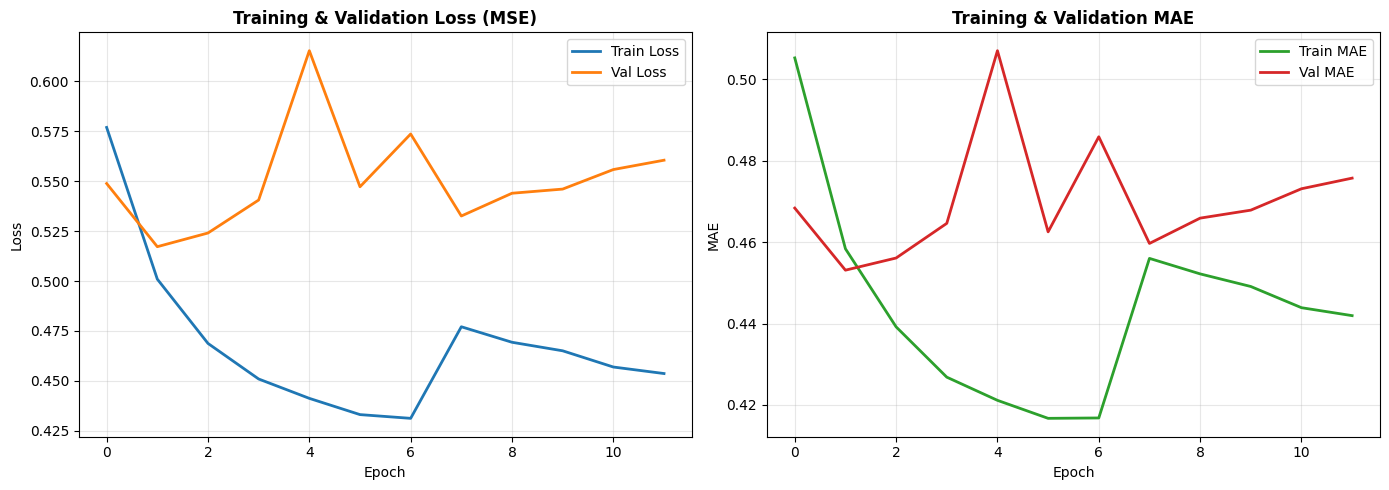

   ✅ Plot saved: training_history.png

📈 Final Statistics:
   Total epochs trained: 12
   Best Train Loss: 0.431262
   Best Val Loss: 0.517186 (epoch 2)

💾 Final model saved: lstm_autoencoder_final.keras
💾 Best model saved: best_autoencoder.keras

✅ Step 4 complete!

🧹 Cleanup options:
   Keep checkpoints for future resuming
   To free space: !rm -rf ./training_checkpoints/backup/


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, BackupAndRestore

# ═══════════════════════════════════════════════════════════
# STEP 4: TRAINING (Resilient & Resumable)
# ═══════════════════════════════════════════════════════════

print("\n" + "="*60)
print("STEP 4: TRAINING (Resumable)")
print("="*60)

# ─────────────────────────────────────────────────────────
# 4.0 إعدادات حفظ الـ Checkpoints
# ─────────────────────────────────────────────────────────

CHECKPOINT_DIR = './training_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LATEST_CKPT = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.weights.h5')
BEST_CKPT = 'best_autoencoder.keras'
HISTORY_FILE = os.path.join(CHECKPOINT_DIR, 'training_history.npz')

print(f"\n📁 Checkpoint directory: {CHECKPOINT_DIR}")
print(f"   Latest weights: {LATEST_CKPT}")
print(f"   Best model: {BEST_CKPT}")

# ─────────────────────────────────────────────────────────
# 4.1 استراتيجية Multi-GPU (إن وجدت)
# ─────────────────────────────────────────────────────────

strategy = tf.distribute.MirroredStrategy() if len(tf.config.list_physical_devices('GPU')) > 1 else tf.distribute.get_strategy()
print(f"\n🖥️ GPUs: {strategy.num_replicas_in_sync}")

# ─────────────────────────────────────────────────────────
# 4.2 Callbacks متقدمة للحماية والاستئناف
# ─────────────────────────────────────────────────────────

print("\n📌 Setting up resilient callbacks...")

callbacks = [
    # 1. حفظ آخر weights تلقائياً كل epoch (للاستئناف)
    ModelCheckpoint(
        LATEST_CKPT,
        monitor='val_loss',
        save_best_only=False,  # ✅ حفظ آخر حالة دائماً
        save_weights_only=True,  # ✅ أخف بكثير من حفظ النموذج كاملاً
        verbose=1
    ),
    
    # 2. حفظ أفضل نموذج (للتقييم النهائي)
    ModelCheckpoint(
        BEST_CKPT,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
        mode='min'
    ),
    
    # 3. BackupAndRestore: يحفظ حالة التدريب كاملة (Optimizer + Epoch + Batch)
    # ✅ هذا هو السر الحقيقي للاستئناف!
    BackupAndRestore(
        backup_dir=os.path.join(CHECKPOINT_DIR, 'backup'),
        save_freq='epoch',  # حفظ كل epoch
        delete_checkpoint=False  # ✅ لا تحذف الـ backup بعد الانتهاء
    ),
    
    # 4. Early Stopping
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    
    # 5. Reduce LR
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
]

print("   ✅ ModelCheckpoint (latest weights every epoch)")
print("   ✅ ModelCheckpoint (best model)")
print("   ✅ BackupAndRestore (full training state)")
print("   ✅ EarlyStopping (patience=10)")
print("   ✅ ReduceLROnPlateau (factor=0.5)")

# ─────────────────────────────────────────────────────────
# 4.3 محاولة استئناف التدريب من Checkpoint سابق
# ─────────────────────────────────────────────────────────

initial_epoch = 0
resumed_history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}

if os.path.exists(LATEST_CKPT):
    print(f"\n🔄 Resuming from checkpoint: {LATEST_CKPT}")
    try:
        model.load_weights(LATEST_CKPT)
        print("   ✅ Weights loaded successfully")
        
        # استعادة الـ history السابق إن وجد
        if os.path.exists(HISTORY_FILE):
            hist_data = np.load(HISTORY_FILE, allow_pickle=True)
            for key in resumed_history.keys():
                if key in hist_data:
                    resumed_history[key] = hist_data[key].tolist()
            initial_epoch = len(resumed_history['loss'])
            print(f"   ✅ History restored: {initial_epoch} epochs completed")
            
    except Exception as e:
        print(f"   ⚠️ Failed to resume: {e}")
        print("   🔄 Starting fresh training...")
        initial_epoch = 0
else:
    print(f"\n🆕 No checkpoint found. Starting fresh training...")

# ─────────────────────────────────────────────────────────
# 4.4 التدريب الفعلي (مع دعم الاستئناف)
# ─────────────────────────────────────────────────────────

print(f"\n🚀 Starting training...")
print(f"   Initial epoch: {initial_epoch}")
print(f"   Target epochs: 50")
print(f"   Batch size: {BATCH_SIZE}")
print("─"*60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    initial_epoch=initial_epoch,  # ✅ يبدأ من هنا إذا كان هناك استئناف
    callbacks=callbacks,
    verbose=1
)

print("─"*60)
print("✅ Training complete!")

# ─────────────────────────────────────────────────────────
# 4.5 دمج الـ History القديم + الجديد
# ─────────────────────────────────────────────────────────

print("\n📊 Merging training history...")

final_history = {}
for key in ['loss', 'val_loss', 'mae', 'val_mae', 'lr']:
    old = resumed_history.get(key, [])
    new = history.history.get(key, [])
    final_history[key] = old + new

# حفظ الـ History المدمج
np.savez(HISTORY_FILE, **{k: np.array(v) for k, v in final_history.items() if v})
print(f"   ✅ History saved: {HISTORY_FILE}")

# ─────────────────────────────────────────────────────────
# 4.6 رسم منحنى التدريب الكامل (القديم + الجديد)
# ─────────────────────────────────────────────────────────

print("\n📊 Plotting complete training history...")

has_mae = 'mae' in final_history and len(final_history['mae']) > 0
num_plots = 2 if has_mae else 1

fig, axes = plt.subplots(1, num_plots, figsize=(7 * num_plots, 5))
if num_plots == 1:
    axes = [axes]

# Loss
axes[0].plot(final_history['loss'], label='Train Loss', linewidth=2, color='#1f77b4')
if 'val_loss' in final_history and len(final_history['val_loss']) > 0:
    axes[0].plot(final_history['val_loss'], label='Val Loss', linewidth=2, color='#ff7f0e')
axes[0].set_title('Training & Validation Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
if has_mae:
    axes[1].plot(final_history['mae'], label='Train MAE', linewidth=2, color='#2ca02c')
    if 'val_mae' in final_history and len(final_history['val_mae']) > 0:
        axes[1].plot(final_history['val_mae'], label='Val MAE', linewidth=2, color='#d62728')
    axes[1].set_title('Training & Validation MAE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("   ✅ Plot saved: training_history.png")

# ─────────────────────────────────────────────────────────
# 4.7 إحصائيات نهائية
# ─────────────────────────────────────────────────────────

print("\n📈 Final Statistics:")
print(f"   Total epochs trained: {len(final_history['loss'])}")
print(f"   Best Train Loss: {min(final_history['loss']):.6f}")

if 'val_loss' in final_history and len(final_history['val_loss']) > 0:
    best_val_idx = np.argmin(final_history['val_loss'])
    print(f"   Best Val Loss: {min(final_history['val_loss']):.6f} (epoch {best_val_idx + 1})")

# ─────────────────────────────────────────────────────────
# 4.8 حفظ النموذج النهائي
# ─────────────────────────────────────────────────────────

# ✅ نحفظ أفضل نموذج (وليس الأخير إذا كان EarlyStopping قد استعاد الأفضل)
model.save('lstm_autoencoder_final.keras')
print(f"\n💾 Final model saved: lstm_autoencoder_final.keras")
print(f"💾 Best model saved: {BEST_CKPT}")
print(f"\n✅ Step 4 complete!")

# ─────────────────────────────────────────────────────────
# 4.9 تنظيف (اختياري: احتفظ بالـ checkpoints للاستئناف المستقبلي)
# ─────────────────────────────────────────────────────────

print("\n🧹 Cleanup options:")
print("   Keep checkpoints for future resuming")
print("   To free space: !rm -rf ./training_checkpoints/backup/")